# Подключение необходимых библиотек

In [13]:
import numpy as np
import cupy as cp # Скачал с помощью команды !pip install cupy-cuda12x
import time

# Основная работа

In [14]:
def test_matrix_multiplication(size):
    print(f"Размерность матрицы: {size}x{size}")

    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)

    # Код выполнения на CPU
    start = time.perf_counter()
    C_cpu = np.dot(A, B)
    cpu_time = time.perf_counter() - start

    # Код выполнения на GPU
    start = time.perf_counter()
    A_gpu = cp.asarray(A)
    B_gpu = cp.asarray(B)
    C_gpu = cp.dot(A_gpu, B_gpu)
    cp.cuda.Stream.null.synchronize()
    gpu_time = time.perf_counter() - start

    # Проверка
    C_gpu_cpu = cp.asnumpy(C_gpu)
    is_close = np.allclose(C_cpu, C_gpu_cpu, rtol=1e-4, atol=1e-4)

    # Вывод результатов
    print(f"Время на CPU: {cpu_time:.7f} сек")
    print(f"Время на GPU: {gpu_time:.7f} сек")
    print(f"Результаты совпадают: {is_close}\n")

    return cpu_time, gpu_time

# Запуск кода

In [15]:
sizes = [100, 300, 500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2000]

# Для графиков
cpu_times = []
gpu_times = []

for s in sizes:
    cpu, gpu = test_matrix_multiplication(s)
    cpu_times.append(cpu)
    gpu_times.append(gpu)

Размерность матрицы: 100x100
Время на CPU: 0.0001042 сек
Время на GPU: 0.0008170 сек
Результаты совпадают: True

Размерность матрицы: 300x300
Время на CPU: 0.0006045 сек
Время на GPU: 0.0004902 сек
Результаты совпадают: True

Размерность матрицы: 500x500
Время на CPU: 0.0021688 сек
Время на GPU: 0.0008726 сек
Результаты совпадают: True

Размерность матрицы: 700x700
Время на CPU: 0.0089077 сек
Время на GPU: 0.0015147 сек
Результаты совпадают: True

Размерность матрицы: 900x900
Время на CPU: 0.0166368 сек
Время на GPU: 0.0025153 сек
Результаты совпадают: True

Размерность матрицы: 1100x1100
Время на CPU: 0.0213555 сек
Время на GPU: 0.0045406 сек
Результаты совпадают: True

Размерность матрицы: 1300x1300
Время на CPU: 0.0413745 сек
Время на GPU: 0.0052802 сек
Результаты совпадают: True

Размерность матрицы: 1500x1500
Время на CPU: 0.0563509 сек
Время на GPU: 0.0071766 сек
Результаты совпадают: True

Размерность матрицы: 1700x1700
Время на CPU: 0.1102541 сек
Время на GPU: 0.0096868 сек
Рез

# Для README на github

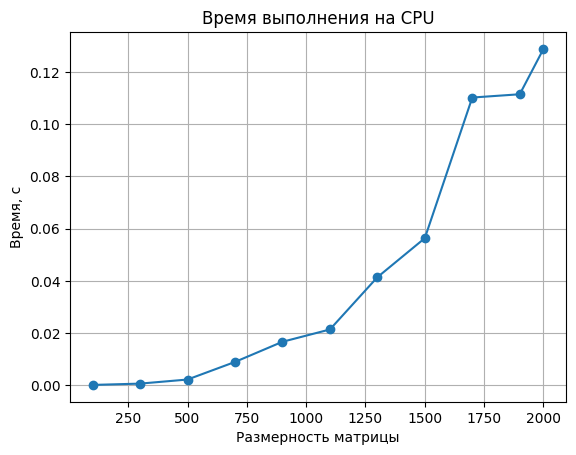

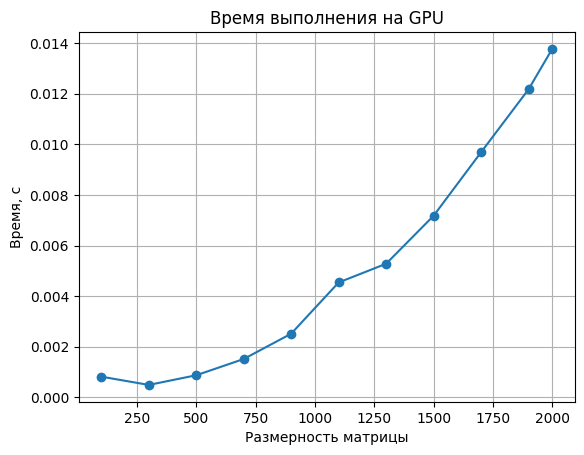

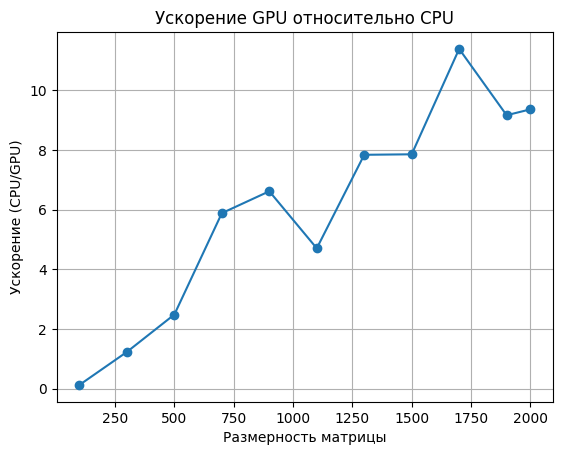

In [16]:
import matplotlib.pyplot as plt

# График 1 - время выполнения на CPU
plt.figure()
plt.plot(sizes, cpu_times, marker='o', linestyle='-')
plt.xlabel('Размерность матрицы')
plt.ylabel('Время, с')
plt.title('Время выполнения на CPU')
plt.grid(True)
plt.show()

# График 2 - время выполнения на GPU
plt.figure()
plt.plot(sizes, gpu_times, marker='o', linestyle='-')
plt.xlabel('Размерность матрицы')
plt.ylabel('Время, с')
plt.title('Время выполнения на GPU')
plt.grid(True)
plt.show()

# График 3 - ускорение (CPU/GPU)
speedups = [cpu / gpu for cpu, gpu in zip(cpu_times, gpu_times)]
plt.figure()
plt.plot(sizes, speedups, marker='o', linestyle='-')
plt.xlabel('Размерность матрицы')
plt.ylabel('Ускорение (CPU/GPU)')
plt.title('Ускорение GPU относительно CPU')
plt.grid(True)
plt.show()